# Lab: Resampling Methods
## CMSE 381 - Spring 2022
## Feb 18, 2022



##ANSWER## 

Instructor notes:

In this module we are going to test out the resampling methods we discussed in class from Chapter 5.

In [1]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# 1. Validation set



The first thing we will do is try out the validation set approach. Dispite what our homework assignments would lead you to believe, we have some fabulous functions available in scikit learn that mean we really don't need to do all this work ourselves.


## Validation set on toy data

First off, let's generate some toy data just to mess around. 

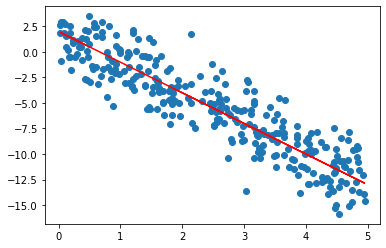

In [2]:
# Set the seed so everyone has the same numbers
np.random.seed(42)

def f(t, m = -3, b = 2):
    return m*t+b

n = 300
X_toy = np.random.uniform(0,5,n)
y_toy = f(X_toy) + np.random.normal(0,2,n)

plt.scatter(X_toy,y_toy)
plt.plot(X_toy,f(X_toy),c = 'red')

Ok, so now we have our fake data set up. Extracting training and testing sets is as simple as the following single line.  

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_toy,y_toy, test_size=0.2, random_state=48824)

One way to see what these sets are is to plot them, although usually we have much higher $p$ (a.k.a. way more input variables) so we can't really visualize like this normally. 

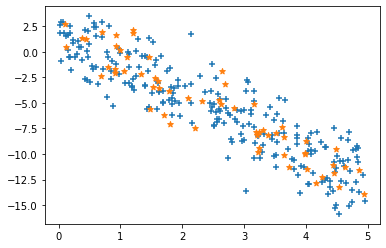

In [4]:
plt.scatter(X_train,y_train, marker = '+')
plt.scatter(X_test,y_test, marker = '*')

&#9989; **<font color=red>Do this:</font>** Set up a linear regression model, train it on the training set, and test it on the test set.  What is your mean squared error? 

In [5]:
##ANSWER##
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train.reshape(-1,1),y_train)
y_hat = model.predict(X_test.reshape(-1,1))

mean_squared_error(y_hat,y_test)

2.942998227759328

## Validation set on diabetes data set

Alrighty that was relatively simple since we have very simple, simulated data.  So instead, let's try this on a real data set. 

Here's a standard toy data set we can import directly from the scikitlearn package. 

In [6]:
import sklearn.datasets

diabetes = sklearn.datasets.load_diabetes(as_frame = True)

In [7]:
X = diabetes['data']
X

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204
2,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022692,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031991,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018118,0.044485
439,0.041708,0.050680,-0.015906,0.017282,-0.037344,-0.013840,-0.024993,-0.011080,-0.046879,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044528,-0.025930


In [8]:
y = diabetes['target']
y

0      151.0
1       75.0
2      141.0
3      206.0
4      135.0
       ...  
437    178.0
438    104.0
439    132.0
440    220.0
441     57.0
Name: target, Length: 442, dtype: float64

Take some time to check out info on the data set: 
- [Documentation in sklearn](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset)
- [Original source for the data](https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html)

&#9989; **<font color=red>Q:</font>** What are each of the columns? What is the value we're predicting? Note some are relatively obvious, the rest you'll need to figure out from the documentation

*Your answer here.*

##ANSWER##

Note: *Students might ask about the sex variable not being 0/1, but there is a note in the documentation about it being mean centered and normalized data*

**From documentation:**


        age age in years

        sex

        bmi body mass index

        bp average blood pressure

        s1 tc, total serum cholesterol

        s2 ldl, low-density lipoproteins

        s3 hdl, high-density lipoproteins

        s4 tch, total cholesterol / HDL

        s5 ltg, possibly log of serum triglycerides level

        s6 glu, blood sugar level


prediction: "quantitative measure of disease progression one year after baseline"


&#9989; **<font color=red>Do this:</font>** 
- Set up linear regression to predict $y$ using the data in $X$. Do this using a 30% validation set. What is the MSE? 
- Repeat the process 100 times and keep track of the MSE. Store these errors in a list called `MSE_Validation`. Hang on to this list, we'll use it later.
- Plot a histogram of the results. What do you notice about the results? (Don't forget to get rid of the fixed seed so this changes each time!). 

In [9]:
# Your code here #

(array([ 3.,  3.,  4., 14., 16., 22., 20., 10.,  4.,  4.]),
 array([2212.32201047, 2365.54026883, 2518.75852719, 2671.97678554,
        2825.1950439 , 2978.41330226, 3131.63156062, 3284.84981897,
        3438.06807733, 3591.28633569, 3744.50459404]),
 <BarContainer object of 10 artists>)

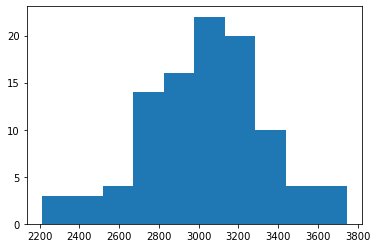

In [10]:
##ANSWER##

MSE_Validation = []

for i in range(100):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=i)
    model = LinearRegression()
    model.fit(X_train,y_train)
    y_hat = model.predict(X_test)

    mse = mean_squared_error(y_hat,y_test)
#     print(mse)
    MSE_Validation.append(mse)
    
plt.hist(MSE_Validation)

#Expecting them to say something about the wide spread

# 2. Leave One Out Cross Validation (LOOCV)

Now that you've spent a bunch of time on homeworks trying to code LOOCV on your own, we get to have the joy of finding out that sklearn has a similarly simple built in procedure to do it. 

As always, the `sklearn` documentation and user guide is an excellent place to start. 

- [LOOCV Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.LeaveOneOut.html)
- [LOOCV User guide](https://scikit-learn.org/stable/modules/cross_validation.html#leave-one-out)

Text(0, 0.5, 'X_2')

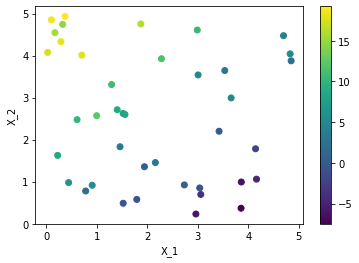

In [11]:
# Let's make a slightly more complicated data set 

# Set the seed so everyone has the same numbers
np.random.seed(42)

def f(t, m1 = -3,m2 = 4, b = 2):
    return m1*t[:,0] + m2*t[:,1]+b

n = 40
X = np.random.uniform(0,5,(n,2))
y = f(X) + np.random.normal(0,2,n)


# Cheap trick for visualization: 
# Show the y value on two dimensions by passing it as the color
plt.scatter(X[:,0],X[:,1], c = y)
plt.colorbar()
plt.xlabel('X_1')
plt.ylabel('X_2')

In [12]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()
loo.get_n_splits(X)

# Notice that trying to print loo doesn't give us much that's useful
print(loo)

LeaveOneOut()


In [13]:
# The power of the function shows up when we use it in a for loop:
for train_index, test_index in loo.split(X):
    print("TRAIN:", train_index, "TEST:", test_index)
    
# Notice that the outputs are the indices we'll want for the train/test 
# splits, NOT the splits of the data themselves

TRAIN: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39] TEST: [0]
TRAIN: [ 0  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39] TEST: [1]
TRAIN: [ 0  1  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39] TEST: [2]
TRAIN: [ 0  1  2  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39] TEST: [3]
TRAIN: [ 0  1  2  3  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39] TEST: [4]
TRAIN: [ 0  1  2  3  4  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39] TEST: [5]
TRAIN: [ 0  1  2  3  4  5  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39] TEST: [6]
TRAIN: [ 0  1  2  3  4  5  6  8  9 10 11 

In [14]:
for train_index, test_index in loo.split(X):

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    print(X_test, y_test)

[[1.87270059 4.75357153]] [16.05871121]
[[3.65996971 2.99329242]] [4.94435081]
[[0.7800932 0.7799726]] [1.82126232]
[[0.29041806 4.33088073]] [18.08095078]
[[3.00557506 3.54036289]] [4.93205643]
[[0.10292247 4.84954926]] [18.69701638]
[[4.1622132  1.06169555]] [-4.61480575]
[[0.90912484 0.91702255]] [5.65319575]
[[1.52121121 2.62378216]] [7.78747475]
[[2.15972509 1.4561457 ]] [3.35247332]
[[3.05926447 0.6974693 ]] [-3.66464416]
[[1.46072324 1.83180922]] [3.65482763]
[[2.28034992 3.92587981]] [11.58526068]
[[0.99836891 2.57117219]] [12.36565517]
[[2.96207284 0.23225206]] [-6.02886236]
[[3.03772426 0.85262062]] [-0.57340299]
[[0.32525796 4.74442769]] [14.76244664]
[[4.82816017 4.04198674]] [5.32727147]
[[1.52306885 0.48836057]] [-0.44167012]
[[3.42116513 2.20076247]] [-0.05846022]
[[0.61019117 2.47588455]] [10.25648623]
[[0.17194261 4.54660201]] [15.6954424]
[[1.29389991 3.31261142]] [10.92940219]
[[1.55855538 2.60034011]] [8.43991943]
[[2.7335514  0.92427228]] [0.45222301]
[[4.84792314 

&#9989; **<font color=red>Do this:</font>** Use the leave one out splits to perform a linear regression on each one, return the mean squared error, and then average over all the values to get the LOOCV error estimation.


In [15]:
# Your code here #

In [16]:
##ANSWER##
MSE = []
for train_index, test_index in loo.split(X):

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model = LinearRegression()
    model.fit(X_train,y_train)
    y_hat = model.predict(X_test)

    mse = mean_squared_error(y_hat,y_test)
#     print(mse)
    MSE.append(mse)
    
print(np.average(MSE))

2.935666501282939


&#9989; **<font color=red>Do this:</font>** Do the same thing as above, but use the `diabetes` data set.


In [17]:
%%time 

# your code here
# Leave the %%time above to have jupyter tell you how much time running LOOCV takes on the diabetes data set

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 7.15 µs


In [18]:
%%time

##ANSWER##

X = diabetes['data']
y = diabetes['target']

loo = LeaveOneOut()

MSE = []
for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index,:], X.iloc[test_index,:]
    y_train, y_test = y[train_index], y[test_index]
    model = LinearRegression()
    model.fit(X_train,y_train)
    y_hat = model.predict(X_test)

    mse = mean_squared_error(y_hat,y_test)
#     print(mse)
    MSE.append(mse)
    
print(np.average(MSE))

3001.746231732946
CPU times: user 5.74 s, sys: 23.9 ms, total: 5.77 s
Wall time: 1.44 s


# 3. k-fold Cross-Validation

Ok, so if you didn't already hate me for having you code up LOOCV on your homework, here goes $k$-fold CV!

(*Note: on your homework you still need to code your own version of $k$-fold CV without using this command.  Think of it as eating your vegetables.  If you only had to eat your vegetables once in your life and then never had to do it again.*)

Below are the links to the documentation for the `KFold` function in `sklearn`.


- [k-fold Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html#sklearn.model_selection.KFold)
- [k-fold User guide](https://scikit-learn.org/stable/modules/cross_validation.html#k-fold)

Text(0, 0.5, 'X_2')

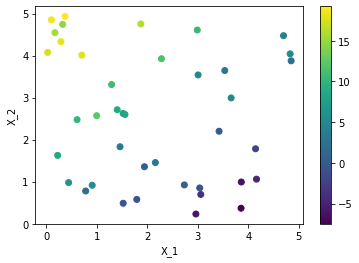

In [19]:
# Regenerating the same data set as before in case we overwrote it at some point 

# Set the seed so everyone has the same numbers
np.random.seed(42)

def f(t, m1 = -3,m2 = 4, b = 2):
    return m1*t[:,0] + m2*t[:,1]+b

n = 40
X = np.random.uniform(0,5,(n,2))
y = f(X) + np.random.normal(0,2,n)


# Cheap trick for visualization: 
# Show the y value on two dimensions by passing it as the color
plt.scatter(X[:,0],X[:,1], c = y)
plt.colorbar()
plt.xlabel('X_1')
plt.ylabel('X_2')

In [20]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=2,shuffle = True)
for train, test in kf.split(X):
    print("Train: %s, Test: %s" % (train, test))


Train: [ 1  2  5  6  7  8 11 14 16 19 21 23 26 27 31 32 33 35 36 38], Test: [ 0  3  4  9 10 12 13 15 17 18 20 22 24 25 28 29 30 34 37 39]
Train: [ 0  3  4  9 10 12 13 15 17 18 20 22 24 25 28 29 30 34 37 39], Test: [ 1  2  5  6  7  8 11 14 16 19 21 23 26 27 31 32 33 35 36 38]


Notice that like the LOOCV function, the KFold function spits out lists of the indices. 

&#9989; **<font color=red>Do this:</font>** Run the $k$-fold validation on our toy data set for $k=5$ to evaluate linear regression. 

In [21]:
# Your code here 

In [22]:
##ANSWER##

MSE = []
kf = KFold(n_splits=5,shuffle = True)

for train_index, test_index in kf.split(X):

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model = LinearRegression()
    model.fit(X_train,y_train)
    y_hat = model.predict(X_test)

    mse = mean_squared_error(y_hat,y_test)
#     print(mse)
    MSE.append(mse)
    
print(np.average(MSE))

3.086470276268984


&#9989; **<font color=red>Do this:</font>** Do the same thing as above to compute $CV_{(5)}$, but use the `diabetes` data set. How does your code speed compare to the LOOCV version?


In [23]:
%%time

# your code here
# Leave the %%time above to have jupyter tell you how much time running k-fold CV takes on the diabetes data set
# If you'd like to see the average compute time taken over multiple runs, you can replace this with %%timeit

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 4.77 µs


In [24]:
%%time


##ANSWER##

X = diabetes['data']
y = diabetes['target']

kf = KFold(n_splits=5,shuffle = True)

MSE = []
for train_index, test_index in kf.split(X):

    X_train, X_test = X.iloc[train_index,:], X.iloc[test_index,:]
    y_train, y_test = y[train_index], y[test_index]
    model = LinearRegression()
    model.fit(X_train,y_train)
    y_hat = model.predict(X_test)

    mse = mean_squared_error(y_hat,y_test)
    MSE.append(mse)
# print(MSE)
print(np.average(MSE))

3023.121239271975
CPU times: user 109 ms, sys: 166 µs, total: 109 ms
Wall time: 29.6 ms


Normally you won't do this but let's just take a look at the difference between $k$-fold CV and the validation method.  Remember how you stored the `MSE_Validation` score list earlier? 

&#9989; **<font color=red>Do this:</font>** Repeat your 5-fold validation set on the diabetes data set 100 times. Keep track of your scores in a list and plot a histogram of these scores on top of a histogram of the `MSE_Validation` list.  What do you notice?


In [25]:
# Your code here #

100
100


(array([ 7., 18., 24., 17., 13., 13.,  1.,  2.,  4.,  1.]),
 array([2964.90926445, 2981.42870318, 2997.94814191, 3014.46758064,
        3030.98701937, 3047.5064581 , 3064.02589683, 3080.54533556,
        3097.06477429, 3113.58421302, 3130.10365175]),
 <BarContainer object of 10 artists>)

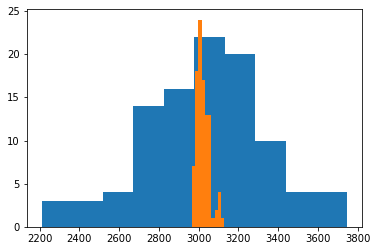

In [26]:
##ANSWER##

X = diabetes['data']
y = diabetes['target']


AllCVScores = []
for j in range(100):
    kf = KFold(n_splits=5,shuffle = True)

    MSE = []
    for train_index, test_index in kf.split(X):

        X_train, X_test = X.iloc[train_index,:], X.iloc[test_index,:]
        y_train, y_test = y[train_index], y[test_index]
        model = LinearRegression()
        model.fit(X_train,y_train)
        y_hat = model.predict(X_test)

        mse = mean_squared_error(y_hat,y_test)
        MSE.append(mse)
    # print(MSE)
    AllCVScores.append(np.average(MSE))

print(len(MSE_Validation))
print(len(AllCVScores))
plt.hist(MSE_Validation)
plt.hist(AllCVScores)


In [27]:
##ANSWER##

#Ideas to add for later but i'm running out of energy. Maybe next year. 

# Again, the textbook has something about messing with the polynomial 
# Can also do something like testing timing, or testing the scores against
# the LOOCV

# 4. The Bootstrap

Our last resampling tool to play with is the bootstrap.  While `sklearn` does have a method called [`Bootstrap`](https://ogrisel.github.io/scikit-learn.org/sklearn-tutorial/modules/generated/sklearn.cross_validation.Bootstrap.html), it doesn't quite do what we want in terms of the example from class.  So instead, we're going to use an even simpler function. 

The main thing we need to do is to sample our data set with replacement, which we can do with the `sample` function built into the data frame. 


First, we'll load in a data set generated the same way we got the data set in Section 5.2. Specifically, $X$ and $Y$ are random variables with mean 0 and unknown variance and covariance $\sigma_X^2$, $\sigma_Y^2$ and $\sigma_{XY}$. 


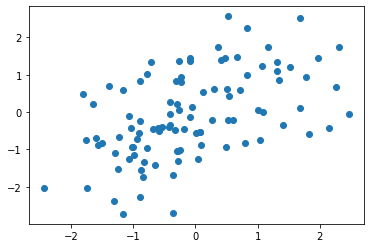

In [28]:
# Let's read in a simple data set, generated in the same way that we got 
# the data in class for two imaginary stock returns.
portfolio = pd.read_csv('Portfolio2.csv',index_col = 0)
plt.scatter(portfolio.X, portfolio.Y)

# WARNING: They call the second column Y, but we're not doing a variable prediction with this guy. 

We're assuming we're investing $\alpha$ percent of our money in stock $X$ and $(1-\alpha)$ percent of our money in stock $Y$. Our goal is to minimize the variance 
$$ \mathrm{Var}(\alpha X + (1-\alpha)Y)$$

From your homework, you showed that the variance is minimized when 
$$
\alpha = \frac{\sigma_Y^2 - \sigma_{XY}}{\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}}
$$

&#9989; **<font color=red>Do this:</font>** Write the function `alpha` below which takes in a data frame and returns the predicted $\hat \alpha$ using the equation above. Use your function on the entire data set to get an estimate $\hat \alpha$.

In [29]:
def alpha(df):
    # Your code here #
    pass
    

alpha(portfolio)

In [30]:
##ANSWER## 

def alpha(df):
    cov = np.array(df.cov())
    sigmaX = cov[0,0]
    sigmaY = cov[1,1]
    sigmaXY = cov[0,1]
    
    num = sigmaY**2 - sigmaXY
    denom = sigmaX**2 + sigmaY **2 - 2 *sigmaXY
    
    return num/denom
    

alpha(portfolio)

0.6262989526220463

We can use the `sample` function to generate a sample of our data frame.  `frac=1` means that we use 100% of our data (so we end up with $n$ samples from our original $n$ data points), and `replace=True` means we get to pick points with replacement 

In [31]:
samp_port = portfolio.sample(frac=1,replace=True)

print('Notice that the `samp_port` dataframe has 100 rows:')
print(len(samp_port.index))

print('\nbut if we get rid of duplicates we have less \nthan 100 data points represented:')
print(len(set(samp_port.index)))
samp_port.head()

Notice that the `samp_port` dataframe has 100 rows:
100

but if we get rid of duplicates we have less 
than 100 data points represented:
66


,X,Y
64,-1.012708,-0.924769
14,1.066469,1.231357
81,0.835180,0.985715
30,-0.851841,-1.741829
71,-0.984357,-1.139160


&#9989; **<font color=red>Do this:</font>** Use your `alpha` function from above to generate 1000 $\hat \alpha$'s and keep them in a list. Draw a histogram of the results. 

In [32]:
# Your code here

In [33]:
##ANSWER## 

alphahats = []
B = 1000

for i in range(B):
    samp_port = portfolio.sample(frac=1,replace=True)
    a = alpha(samp_port)
    alphahats.append(a)

alphahats[:10]

[0.7266680291326105,
 0.9040016387089074,
 0.5509916566597595,
 0.6391387970184409,
 0.5965172896684567,
 0.5987465017383081,
 0.42321153192174105,
 0.6849822551539234,
 0.594720688083404,
 0.78792275221231]

(array([  4.,  15.,  59., 138., 202., 226., 179., 113.,  53.,  11.]),
 array([0.1743428 , 0.25767291, 0.34100303, 0.42433314, 0.50766326,
        0.59099337, 0.67432349, 0.7576536 , 0.84098372, 0.92431383,
        1.00764395]),
 <BarContainer object of 10 artists>)

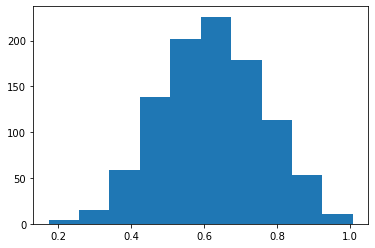

In [34]:
##ANSWER##

plt.hist(alphahats)

&#9989; **<font color=red>Do this:</font>** Use your alphas to determine the standard error of $\hat \alpha$ using Eqn 5.8 from the book.

In [35]:
##ANSWER##

alpha_avg = np.average(alphahats)
np.sqrt( np.sum ( (alphahats - alpha_avg)**2 ) / (B-1))

# Why is this so far off from the version in the book? 
# I'm not getting the same estimate for alpha hat either. 

0.14113530593729426

##ANSWER## 

*Idea for later but i'm just outta juice*

The bootstrap for linear regression:

The book has a version of this where we do bootstrap estimation of linear regression variables, and compares them to the standard error automatically computed by the stats package (or maybe we can hard code the quantity?

# Lab Survey

To get credit for today's lab, fill out the following survey before the end of class:

https://forms.gle/hX8GT5FJ2fNMeTo1A

Note this is the same link for every lab, so you will fill this out multiple times this semester.



-----
### Congratulations, we're done!
Written by Dr. Liz Munch, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

In [39]:
##ANSWER## 
# This cell gets the name of the current notebook. Needs a sec
# to run before it works

from jupyterinstruct import InstructorNotebook
this_notebook = InstructorNotebook.getname()


##ANSWER## 

<IPython.core.display.Javascript object>

In [40]:
##ANSWER##
#This cell runs the converter which removes ANSWER fields, renames the notebook and cleans out output fields. 

studentnotebook = InstructorNotebook.makestudent(this_notebook)
InstructorNotebook.validate(studentnotebook)

Myfilename Lab-Resampling-INSTRUCTOR.ipynb


Lab-Resampling.ipynb


Validating Notebook ./Lab-Resampling.ipynb
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..


5